<a href="https://colab.research.google.com/github/owlmt/QuantumSecurity/blob/main/Grover_Toy_AES_KeySearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grover's Algorithm vs. Symmetric Crypto — a Toy AES-style Key Search on Aer

The companion to the Shor notebooks. **Shor** breaks *asymmetric* crypto (RSA, ECC) outright;
**Grover** only gives a *quadratic* speedup against *symmetric* crypto (block ciphers, hashes) —
it halves the effective key/preimage bits. This notebook demonstrates the mechanism: a tiny
AES-flavoured block cipher whose secret key is recovered by Grover search from a single known
plaintext/ciphertext pair, on the **Aer simulator**.

## ⚠️ Why this is a toy, not "breaking AES"

Grover's quadratic speedup is far weaker than Shor's exponential one, and the real targets are
hopelessly out of reach:

| Target | Grover iterations | Logical qubits | Feasible? |
|---|---|---|---|
| This toy (4-bit key) | ~3 | 8 | yes, on Aer |
| **AES-128** | ~$2^{64}$ | ~2,950 (Grassl et al. 2016) | no |
| **AES-256** | ~$2^{128}$ | ~6,600 | no |
| **SHA-256 preimage** | ~$2^{128}$ | thousands | no |

$2^{64}$ sequential oracle calls is millennia even at billions/sec, and the circuits need
thousands of fault-tolerant qubits. This is exactly why doubling the key length (AES-256) is
considered a sufficient response to quantum search. **The toy below gives zero practical uplift
against real ciphers** — it illustrates amplitude amplification, nothing more.

In [1]:
# Colab setup
!pip install -q qiskit qiskit-aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.0 MB/s eta 0:00:00


## Part 1 — Grover warm-up: amplitude amplification

Grover finds a marked item in an unstructured space of $N=2^n$ in $\approx\frac{\pi}{4}\sqrt{N/M}$
steps ($M$ = number of solutions). Each step is **oracle** (phase-flip the solutions) then
**diffuser** (reflect about the mean). We first mark a single 3-bit string $|101\rangle$.

2 Grover iterations; marked = 101


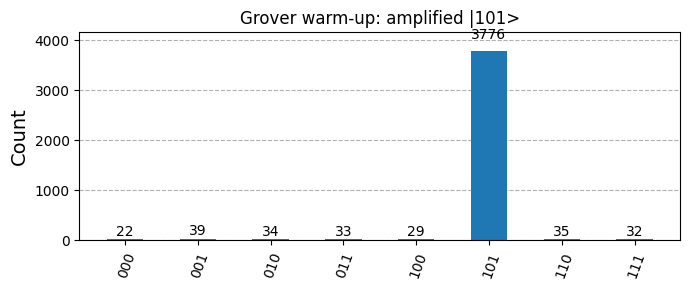

In [2]:
import numpy as np, math
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import UnitaryGate, ZGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

sim = AerSimulator()
n = 3
marked = '101'

q = QuantumRegister(n, 'q'); c = ClassicalRegister(n, 'm')
g = QuantumCircuit(q, c)
g.h(q)
iters = round(math.pi/4*math.sqrt(2**n))
for _ in range(iters):
    # oracle: phase-flip |101>
    for i,bit in enumerate(reversed(marked)):
        if bit=='0': g.x(q[i])
    g.append(ZGate().control(n-1), q[:])
    for i,bit in enumerate(reversed(marked)):
        if bit=='0': g.x(q[i])
    # diffuser
    g.h(q); g.x(q); g.append(ZGate().control(n-1), q[:]); g.x(q); g.h(q)
g.measure(q, c)
counts = sim.run(transpile(g, sim), shots=4000).result().get_counts()
print(f"{iters} Grover iterations; marked = {marked}")
plot_histogram(counts, figsize=(7,3), title=f"Grover warm-up: amplified |{marked}>")

## Part 2 — A toy AES-style block cipher

A 4-bit-block, 4-bit-key, 2-round **substitution-permutation network** (the structure AES uses):
- **S-box** (nonlinear substitution): the real 4-bit **PRESENT** S-box.
- **Permutation** layer: a 1-bit rotation (diffusion).
- **Key schedule**: round-2 key $K_2 = \mathrm{rotl}(K)\oplus 9$.

$$\text{Enc}_K(P)=S\big(\,\mathrm{rotl}(S(P\oplus K))\oplus K_2\,\big)$$

The attacker is given one plaintext/ciphertext pair $(P,C)$ and must find $K$ — the symmetric-key
analogue of what AES key-search faces.

In [3]:
SBOX = [0xC,0x5,0x6,0xB,0x9,0x0,0xA,0xD,0x3,0xE,0xF,0x8,0x4,0x7,0x1,0x2]  # PRESENT S-box
def rotl4(v): return ((v<<1)|(v>>3)) & 0xF
def enc(P, K):
    K2 = rotl4(K) ^ 0x9
    return SBOX[ rotl4(SBOX[P ^ K]) ^ K2 ]

P, K_secret = 0b0000, 0b1000
C = enc(P, K_secret)
preimages = [k for k in range(16) if enc(P, k) == C]
print(f"plaintext  P = {P:04b}")
print(f"SECRET key K = {K_secret:04b}   (hidden from Grover)")
print(f"ciphertext C = Enc_K(P) = {C:04b}")
print(f"keys with Enc_k(P)=C : {[f'{k:04b}' for k in preimages]}  (unique target)")
assert preimages == [K_secret]

plaintext  P = 0000
SECRET key K = 1000   (hidden from Grover)
ciphertext C = Enc_K(P) = 0001
keys with Enc_k(P)=C : ['1000']  (unique target)


### Reversible quantum encryption, and a check against the classical cipher

The S-box and rotation are bijections on 4 bits → permutation gates. Key XOR = `CX` from key
qubits into the block. We verify the quantum circuit reproduces the classical cipher for **all 16
keys** before trusting it inside the oracle.

In [4]:
def perm_gate(table, label):
    M = np.zeros((16,16))
    for v,o in enumerate(table): M[o,v]=1
    return UnitaryGate(M, label=label)
SG = perm_gate(SBOX, "S")
RG = perm_gate([rotl4(v) for v in range(16)], "rot")

def enc_gate():
    k=QuantumRegister(4,'k'); b=QuantumRegister(4,'b'); c=QuantumCircuit(k,b,name="Enc")
    for i in range(4): c.cx(k[i], b[i])              # round-1 key XOR
    c.append(SG, b[:]); c.append(RG, b[:])           # S-box, rotate
    c.cx(k[3],b[0]); c.x(b[0])                        # round-2 key XOR: K2 = rotl(K)^9
    c.cx(k[0],b[1]); c.cx(k[1],b[2])
    c.cx(k[2],b[3]); c.x(b[3])
    c.append(SG, b[:])                               # S-box
    return c

# verify quantum Enc == classical Enc for every key
key=QuantumRegister(4,'k'); blk=QuantumRegister(4,'b')
ok=True
for Kt in range(16):
    t=QuantumCircuit(key,blk)
    for i in range(4):
        if (Kt>>i)&1: t.x(key[i])
        if (P>>i)&1:  t.x(blk[i])
    t.compose(enc_gate(), inplace=True); t.save_statevector()
    sv=sim.run(t).result().get_statevector()
    blkval=(int(np.argmax(np.abs(sv.data)))>>4)&0xF
    ok &= (blkval==enc(P,Kt))
print("quantum Enc matches classical Enc for all 16 keys:", ok)

quantum Enc matches classical Enc for all 16 keys: True


## Part 3 — The Grover key-recovery oracle

The oracle must phase-flip exactly the keys with $\text{Enc}_K(P)=C$, **without being told $K$**:
1. **Encrypt**: compute $|K\rangle|P\rangle \to |K\rangle|\text{Enc}_K(P)\rangle$.
2. **Mark**: phase-flip the block component equal to $C$ (X-mask $C$'s zero bits + multi-controlled-Z).
3. **Uncompute**: apply $\text{Enc}^{-1}$ so the block returns to $|P\rangle$, leaving the phase on $|K\rangle$.

Then the diffuser reflects the key register about its mean. We wrap oracle and diffuser as named
gates for a readable circuit.

Grover iterations: 3


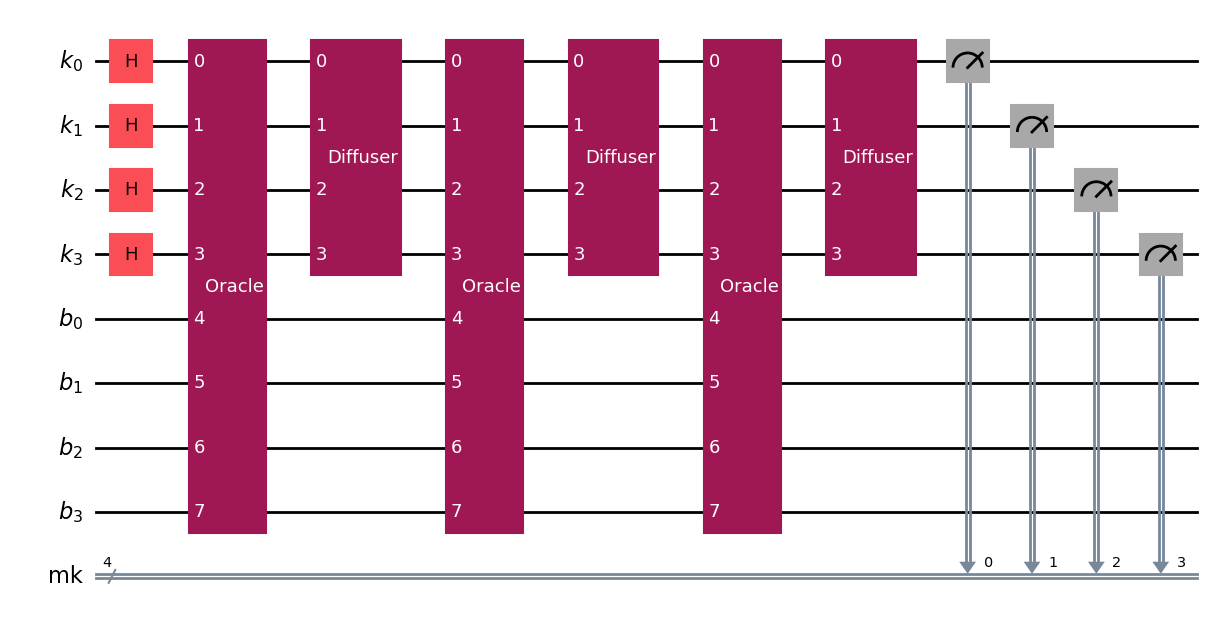

In [5]:
def oracle_gate():
    k=QuantumRegister(4,'k'); b=QuantumRegister(4,'b'); c=QuantumCircuit(k,b,name="Oracle")
    E=enc_gate().to_gate()
    c.append(E, k[:]+b[:])                            # encrypt
    for i in range(4):
        if not ((C>>i)&1): c.x(b[i])                  # mark block == C
    c.append(ZGate().control(3), [b[0],b[1],b[2],b[3]])
    for i in range(4):
        if not ((C>>i)&1): c.x(b[i])
    c.append(E.inverse(), k[:]+b[:])                  # uncompute
    return c

def diffuser_gate():
    k=QuantumRegister(4,'k'); c=QuantumCircuit(k,name="Diffuser")
    c.h(k); c.x(k); c.append(ZGate().control(3), k[:]); c.x(k); c.h(k)
    return c

key=QuantumRegister(4,'k'); blk=QuantumRegister(4,'b'); cl=ClassicalRegister(4,'mk')
qc=QuantumCircuit(key, blk, cl)
qc.h(key)                                             # uniform over 16 keys; block stays |P=0000>
O=oracle_gate().to_gate(); D=diffuser_gate().to_gate()
iters = round(math.pi/4*math.sqrt(16))                # 1 solution in 16 -> 3
for _ in range(iters):
    qc.append(O, key[:]+blk[:]); qc.append(D, key[:])
qc.measure(key, cl)
print(f"Grover iterations: {iters}")
qc.draw('mpl', fold=-1)

### Inside one oracle (the encrypt → mark → uncompute structure)

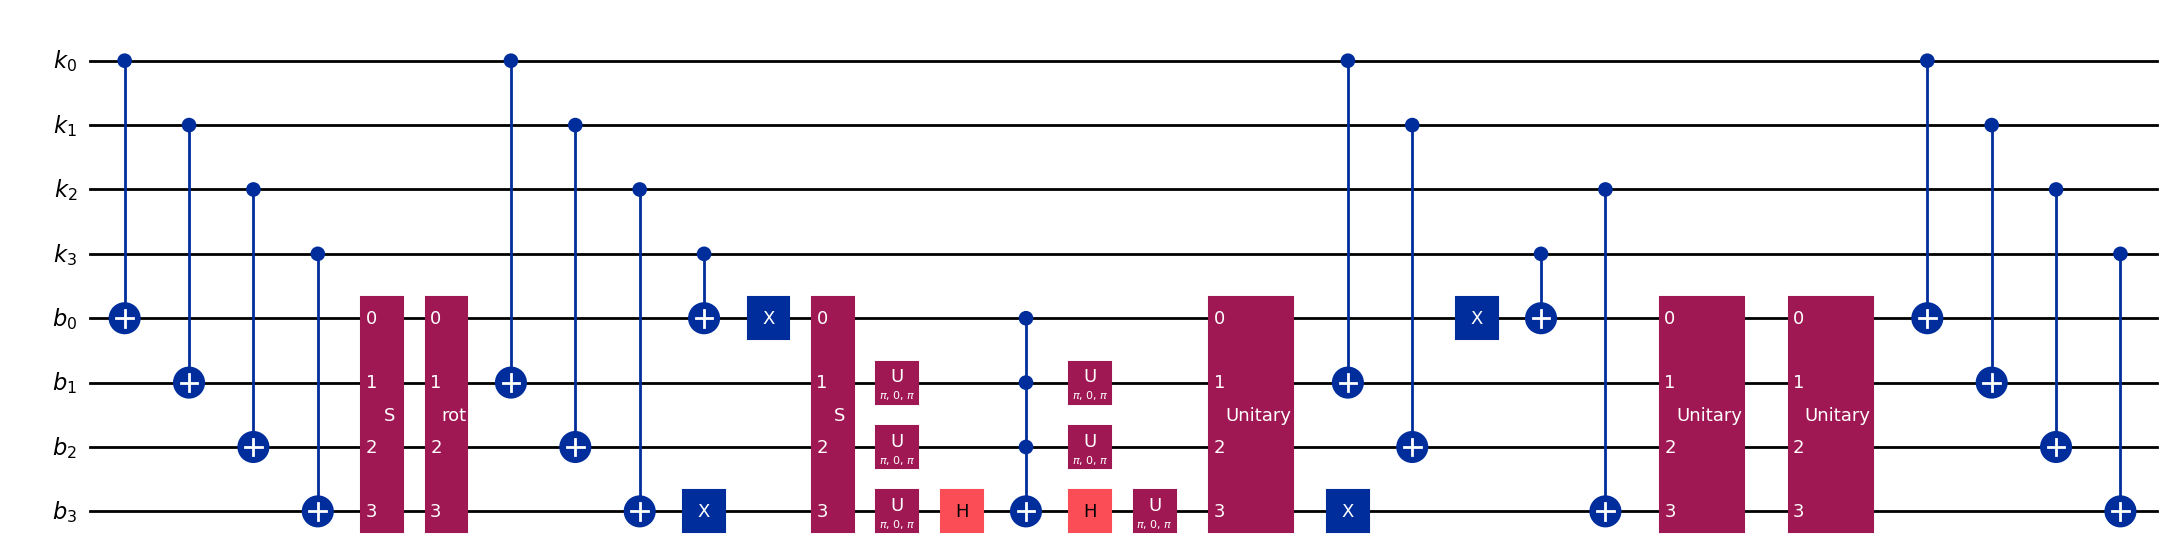

In [6]:
oracle_gate().decompose().draw('mpl', fold=-1)

## Part 4 — Run on Aer and recover the key

CX gates: 48   depth: 56

measured keys:
  1000  (K= 8)   p=0.958  <-- SECRET KEY
  0011  (K= 3)   p=0.005
  0111  (K= 7)   p=0.004
  1111  (K=15)   p=0.004
  0100  (K= 4)   p=0.003

RECOVERED KEY = 1000   (secret = 1000, success p = 0.958)


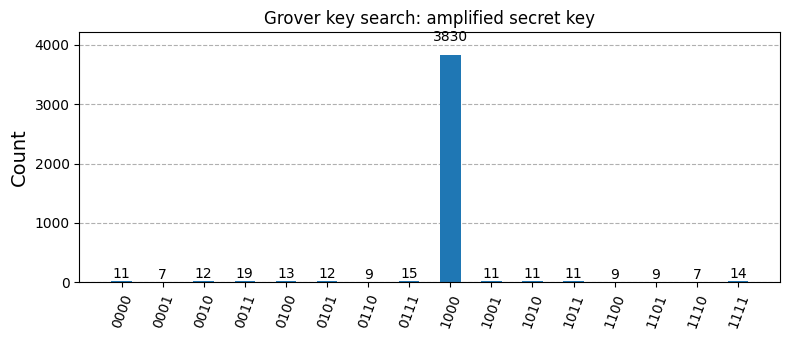

In [7]:
tqc = transpile(qc, sim)
counts = sim.run(tqc, shots=4000).result().get_counts()
tot = sum(counts.values())
print(f"CX gates: {tqc.count_ops().get('cx',0)}   depth: {tqc.depth()}\n")
print("measured keys:")
for bs,cnt in sorted(counts.items(), key=lambda kv:-kv[1])[:5]:
    tag = '  <-- SECRET KEY' if int(bs,2)==K_secret else ''
    print(f"  {bs}  (K={int(bs,2):>2})   p={cnt/tot:.3f}{tag}")
best=max(counts, key=counts.get)
print(f"\nRECOVERED KEY = {int(best,2):04b}   (secret = {K_secret:04b}, "
      f"success p = {counts[best]/tot:.3f})")
assert int(best,2)==K_secret
plot_histogram(counts, figsize=(8,3.5), title='Grover key search: amplified secret key')

## Part 5 — Scaling reality

Grover needs $\frac{\pi}{4}\sqrt{2^{\,b}}$ oracle calls for a $b$-bit key — i.e. it turns a
$b$-bit key into roughly $b/2$ bits of effective security. That is a real but modest dent:

In [8]:
import math
print(f"{'target':18s}{'key bits':>9}{'Grover iterations':>22}{'feasible?':>12}")
for name, b in [("toy cipher", 4), ("AES-128", 128), ("AES-256", 256), ("SHA-256 preimage", 256)]:
    it = (math.pi/4)*math.sqrt(2**b)
    exp = math.log2(it)
    feasible = "yes" if b <= 24 else "NO"
    print(f"{name:18s}{b:>9}{('~2^%.0f' % exp):>22}{feasible:>12}")
print("\nGrover halves key security (AES-128 -> ~2^64 effort). The standard countermeasure is")
print("simply to double the key length: AES-256 keeps ~2^128 effort even against Grover.")

target             key bits     Grover iterations   feasible?
toy cipher                4                  ~2^2         yes
AES-128                 128                 ~2^64          NO
AES-256                 256                ~2^128          NO
SHA-256 preimage        256                ~2^128          NO

Grover halves key security (AES-128 -> ~2^64 effort). The standard countermeasure is
simply to double the key length: AES-256 keeps ~2^128 effort even against Grover.


### Notes

- **Hash preimage** is the *same* machinery: replace the cipher oracle "$\text{Enc}_K(P)=C$" with
  "$h(x)=\text{target}$" — compute a (toy) reversible hash, mark the matching output, uncompute,
  diffuse. Grover then finds a preimage in $\sqrt N$ instead of $N$.
- **Honesty about the oracle.** Here the oracle is the *actual* reversible cipher circuit, so
  Grover is never told the key — the only thing precomputed classically is the target $(P,C)$,
  which is public knowledge in a known-plaintext attack. Real attacks compile AES/SHA gate-by-gate
  the same way; only the size differs (by dozens of orders of magnitude).
- To experiment: change `K_secret`, raise the block/key width, or add rounds. Beyond ~24 search
  qubits the statevector stops fitting in memory — the same wall that protects real ciphers.